# Importación de librerías

In [ ]:
from collections import Counter

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import hdbscan

from sklearn.cluster import KMeans, OPTICS, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score

from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer

from sklearn.manifold import TSNE
import umap

# Importación de datos

In [ ]:
planetas = pd.read_csv("planetas.csv", comment='#')

# Exploración de datos

Primero, revisamos los valores faltantes de las columnas a utilizar:

In [ ]:
planetas[['pl_rade','pl_bmasse','pl_orbper','pl_eqt','pl_orbsmax','pl_insol',"pl_orbeccen","pl_insol"]].isna().sum()

,0
pl_rade,50
pl_bmasse,31
pl_orbper,339
pl_eqt,1600
pl_orbsmax,428
pl_insol,1876
pl_orbeccen,1052
pl_insol,1876


Revisamos la correlación de las columnas en general

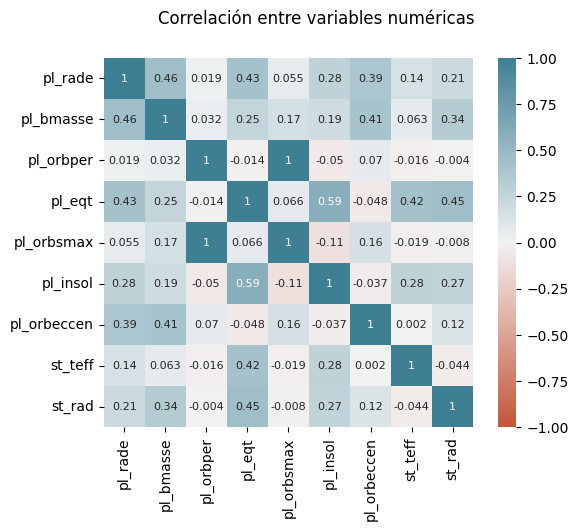

In [ ]:
numeric_cols = [
    'pl_rade', 'pl_bmasse', 'pl_orbper', 'pl_eqt', 'pl_orbsmax', 'pl_insol', 'pl_orbeccen',
    'st_teff', 'st_rad'
]

planetas = planetas.loc[:, ["pl_name"] + numeric_cols]

sns.heatmap(
    round(planetas[numeric_cols].corr(), 3),
    vmin = -1, vmax = 1, center = 0,
    cmap = sns.diverging_palette(20, 220, n = 256),
    annot = True,
    annot_kws={'fontsize': 8},
    square = True
)

plt.suptitle("Correlación entre variables numéricas")
plt.show()

In [ ]:
def plot_column(col, title):
  fig, axs = plt.subplots(figsize=(10, 5), ncols=2)
  sns.histplot(planetas[col], ax=axs[0])
  sns.boxplot(planetas[col], ax=axs[1], orient='h')
  plt.suptitle(title)
  plt.savefig(f"{title}.png")
  plt.show()

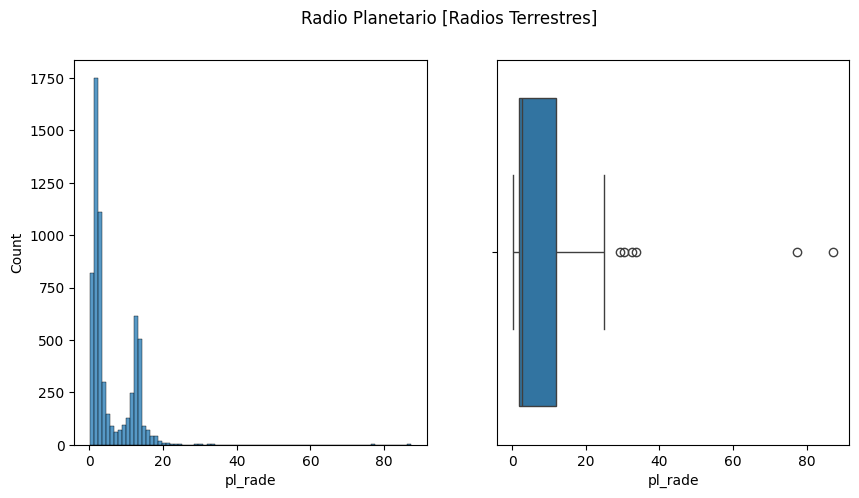

In [ ]:
col = "pl_rade"
title = "Radio Planetario [Radios Terrestres]"

plot_column(col, title)
planetas = planetas[planetas["pl_rade"] < 40]

Observando que los outliers son aquellos que se encuentran por encima de 40, decidimos removerlos

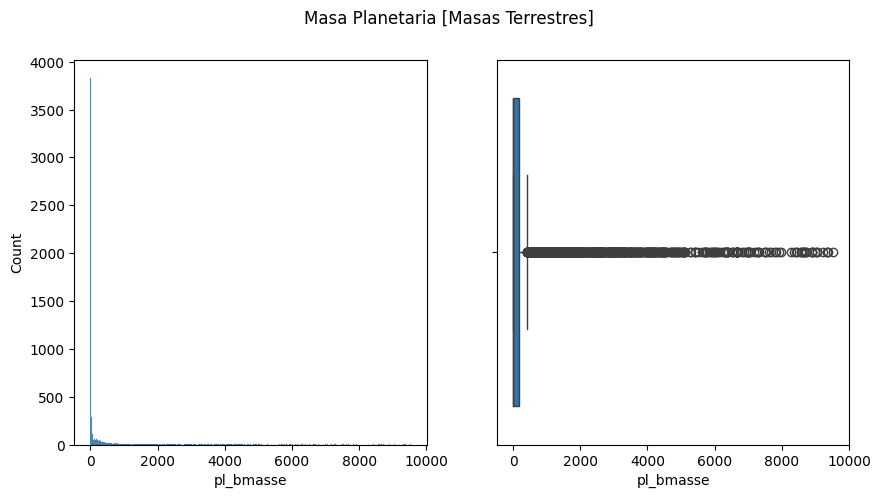

In [ ]:
col = "pl_bmasse"
title = "Masa Planetaria [Masas Terrestres]"

plot_column(col, title)

A pesar de la rara distribución, no quitamos nada porque termina quitando demasiados datos

In [ ]:
q = planetas['pl_orbper'].quantile(0.99)
planetas = planetas[planetas['pl_orbper'] < q]
planetas['pl_orbper'].describe()

,pl_orbper
count,5828.000000
mean,231.844537
std,968.253407
min,0.112007
25%,4.250839
50%,10.444168
75%,35.500435
max,13921.423020


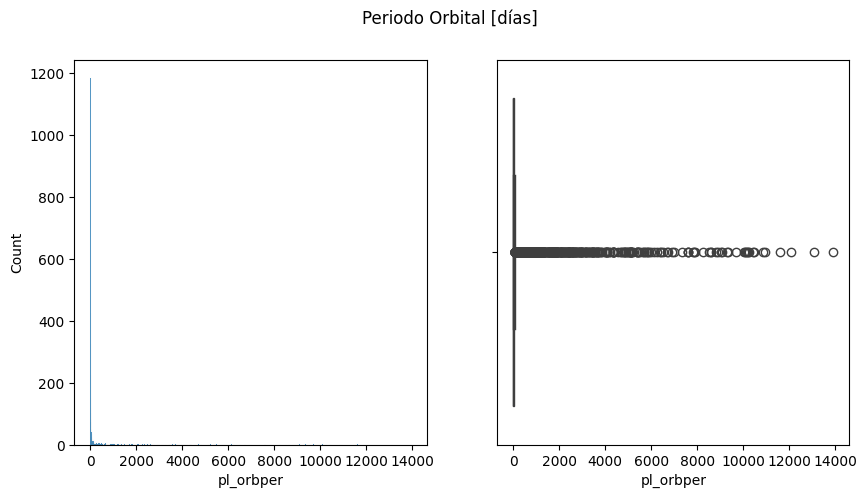

In [ ]:
col = "pl_orbper"
title = "Periodo Orbital [días]"

plot_column(col, title)

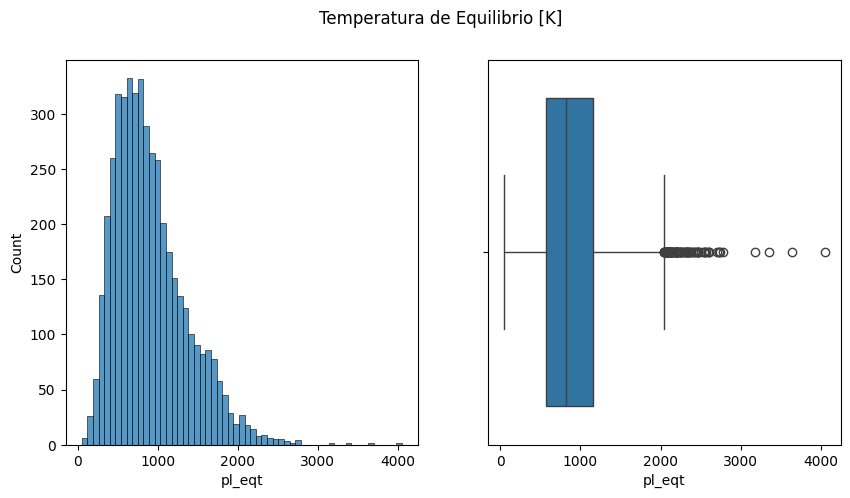

In [ ]:
col = "pl_eqt"
title = "Temperatura de Equilibrio [K]"

plot_column(col, title)

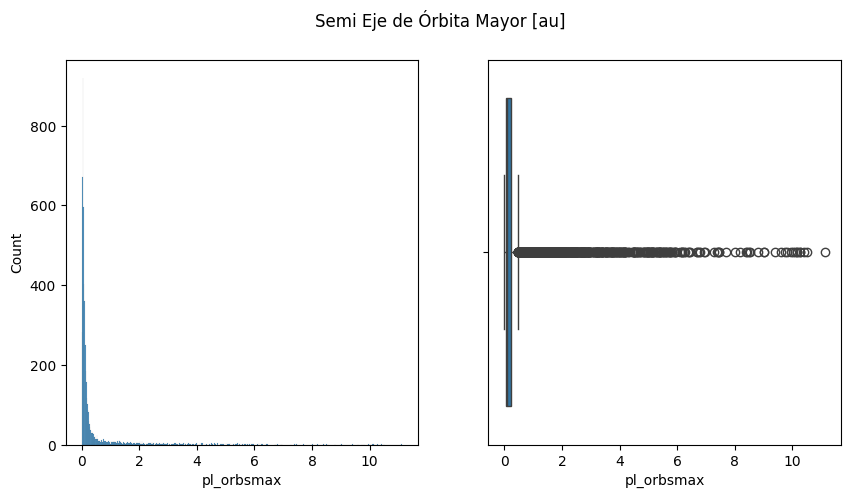

In [ ]:
col = "pl_orbsmax"
title = "Semi Eje de Órbita Mayor [au]"

plot_column(col, title)

In [ ]:
print(f"Planetas que quedan: {len(planetas)}")

Planetas que quedan: 5828


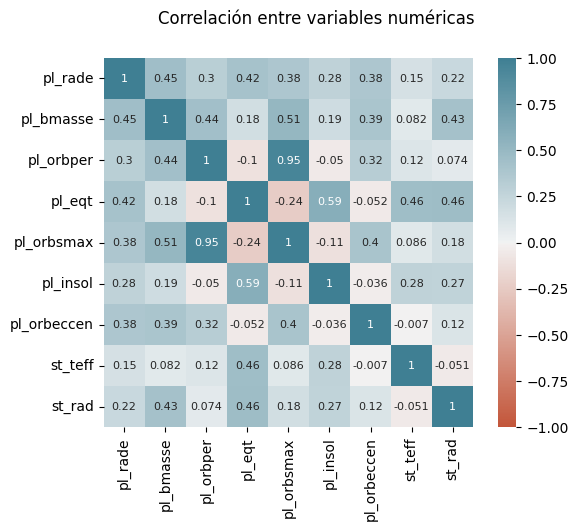

In [ ]:
sns.heatmap(
    round(planetas[numeric_cols].corr(), 3),
    vmin = -1, vmax = 1, center = 0,
    cmap = sns.diverging_palette(20, 220, n = 256),
    annot = True,
    annot_kws={'fontsize': 8},
    square = True
)

plt.suptitle("Correlación entre variables numéricas")
plt.savefig("Correlación de variables.png")
plt.show()

# Preprocesamiento de datos

Se hizo una clasificación de exoplanetas por tipo según la masa:

In [ ]:
def clasificar(row):
    r = row['pl_rade']
    m = row['pl_bmasse']

    if pd.isna(r) and pd.isna(m):
        return 'Sin clasificar'

    if not pd.isna(r):
        if r < 1.25:   return 'Terrestre'
        elif r < 2.0:  return 'Super-Tierra'
        elif r < 4.0:  return 'Sub-Neptuno'
        elif r < 10.0: return 'Neptuniano'
        else:          return 'Gigante gaseoso'

#checar masas, especialmente las obtenidas por velocidad radial
    if not pd.isna(m):
        if m < 2:    return 'Terrestre'
        elif m < 10: return 'Super-Tierra'
        elif m < 20: return 'Sub-Neptuno'
        elif m < 50: return 'Neptuniano'
        else:        return 'Gigante gaseoso'

planetas['tipo_planeta'] = planetas.apply(clasificar, axis=1)
print(planetas['tipo_planeta'].value_counts())

tipo_planeta
Sub-Neptuno        2037
Gigante gaseoso    1488
Super-Tierra       1180
Terrestre           571
Neptuniano          552
Name: count, dtype: int64


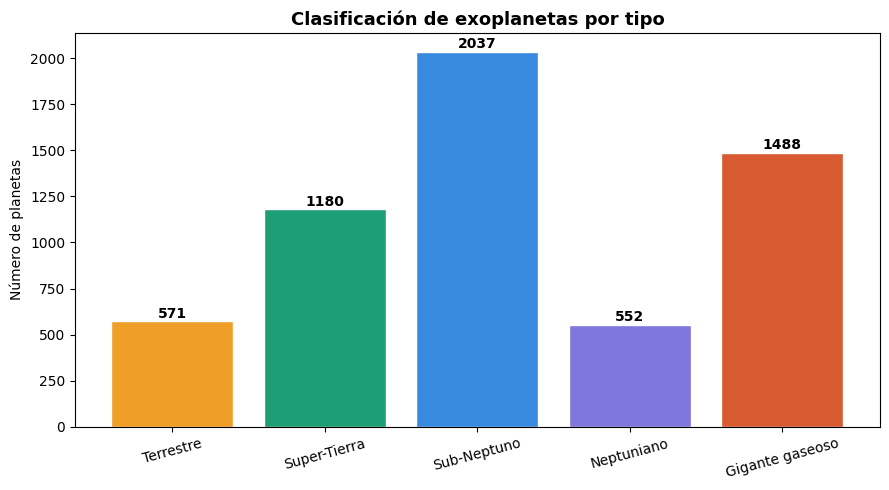

In [ ]:
conteo = planetas['tipo_planeta'].value_counts()

colores = {
    'Terrestre':       '#EF9F27',
    'Super-Tierra':    '#1D9E75',
    'Sub-Neptuno':     '#378ADD',
    'Neptuniano':      '#7F77DD',
    'Gigante gaseoso': '#D85A30',
    'Sin clasificar':  '#888780'
}

orden = ['Terrestre', 'Super-Tierra', 'Sub-Neptuno', 'Neptuniano', 'Gigante gaseoso']
valores = [conteo[t] for t in orden]
colores_ord = [colores[t] for t in orden]

plt.figure(figsize=(9, 5))
bars = plt.bar(orden, valores, color=colores_ord, edgecolor='white')

for bar, val in zip(bars, valores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             str(val), ha='center', fontsize=10, fontweight='bold')

plt.title('Clasificación de exoplanetas por tipo', fontsize=13, fontweight='bold')
plt.ylabel('Número de planetas')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("Clasificación de exoplanetas.png")
plt.show()

In [ ]:
print(planetas[planetas['tipo_planeta'] == 'Sin clasificar']['pl_name'])
# 7 planetas sin clasificar

Series([], Name: pl_name, dtype: object)


Revisamos las temperaturas de equilibrio faltantes para cada tipo de planeta

In [ ]:
# Equilibrium Temperature [K]
print(planetas.groupby('tipo_planeta')['pl_eqt'].apply(lambda x: x.isna().sum()))

tipo_planeta
Gigante gaseoso    712
Neptuniano         129
Sub-Neptuno        233
Super-Tierra        97
Terrestre           54
Name: pl_eqt, dtype: int64


Ahora, vamos a calcular la temperatura de la estrella

In [ ]:
# Stellar Effective Temperature [K]
print(f"Faltantes st_teff:\t{planetas['st_teff'].isna().sum()}")
# Stellar Radius [Solar Radius]
print(f"Faltantes st_rad:\t{planetas['st_rad'].isna().sum()}")
# Orbit Semi-Major Axis [au]
print(f"Faltantes pl_orbsmax:\t{planetas['pl_orbsmax'].isna().sum()}")

Faltantes st_teff:	21
Faltantes st_rad:	31
Faltantes pl_orbsmax:	413


In [ ]:
mask = planetas['st_teff'].notna() & planetas['st_rad'].notna() & planetas['pl_orbsmax'].notna()
print(f"Planetas con las 3 variables completas: {mask.sum()}")
print(f"Planetas sin al menos una: {(~mask).sum()}")

Planetas con las 3 variables completas: 5381
Planetas sin al menos una: 447


In [ ]:
def calcular_temp_eq(row):
    # Si ya tiene temperatura medida, la dejamos
    if not pd.isna(row['pl_eqt']):
        return row['pl_eqt']

    # Si tiene las 3 variables, calculamos con la fórmula
    if not pd.isna(row['st_teff']) and not pd.isna(row['st_rad']) and not pd.isna(row['pl_orbsmax']):
        A = 0.3
        T_star = row['st_teff']
        R_star = row['st_rad'] * 6.957e8  # radios solares a metros
        r = row['pl_orbsmax'] * 1.496e11  # AU a metros
        T_eq = T_star * ((R_star / (2 * r)) ** 0.5) * ((1 - A) ** 0.25)
        return T_eq

    return np.nan

planetas['pl_eqt'] = planetas.apply(calcular_temp_eq, axis=1)
print(f"Después de la fórmula, faltantes: {planetas['pl_eqt'].isna().sum()}")

Después de la fórmula, faltantes: 238


De los planetas que aún tiene un valor faltante, revisamos cuáles tienen flujo en unidades solares:

In [ ]:
# T_eq = 278.5 * (F)^0.25   donde F es el flujo en unidades solares
# F = Insolation Flux [Earth Flux]
sin_temp = planetas['pl_eqt'].isna()
print(f"Planetas CON flujo: {(sin_temp & planetas['pl_insol'].notna()).sum()}")
print(f"Planetas SIN flujo: {(sin_temp & planetas['pl_insol'].isna()).sum()}")

Planetas CON flujo: 0
Planetas SIN flujo: 238


Imputamos los datos faltantes por medio de KNN

In [ ]:
num_df = planetas.loc[:, numeric_cols]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(num_df)

imputer = KNNImputer(n_neighbors=5)
X_scaled_imputed = imputer.fit_transform(X_scaled)

X_imputed = scaler.inverse_transform(X_scaled_imputed)

planetas.loc[:, numeric_cols] = X_imputed

In [ ]:
planetas = planetas.dropna(subset=['pl_eqt'])
print(f"Planetas restantes: {len(planetas)}")

Planetas restantes: 5828


# Construcción de modelos

Normalización de los datos para la aplicación de los algoritmos de clustering

In [ ]:
num_df = planetas.loc[:, numeric_cols]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(num_df)

In [ ]:
# tsne = TSNE(n_components=2, random_state=42, perplexity=30)
# X_pos = tsne.fit_transform(X_scaled)

reducer = umap.UMAP(n_components=2)
X_pos = reducer.fit_transform(X_scaled)

planetas['x'] = X_pos[:, 0]
planetas['y'] = X_pos[:, 1]

In [ ]:
cols_clustering = ['pl_rade', 'pl_bmasse', 'pl_orbper', 'pl_eqt', 'pl_orbsmax']
X_clustering_data = planetas[cols_clustering]
X = X_clustering_data.dropna()
idx = X.index

## K-Means

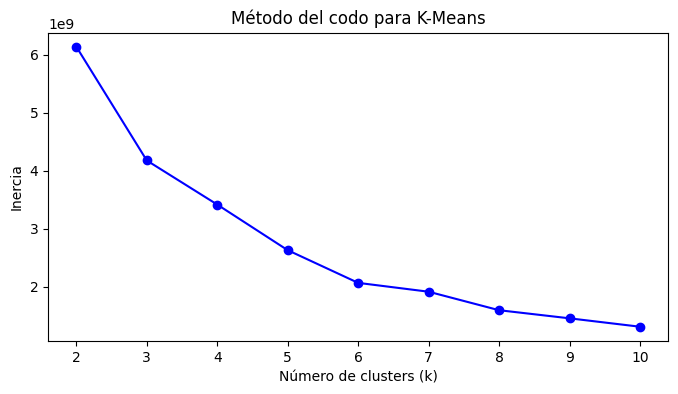

In [ ]:
inercias = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inercias.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_values, inercias, 'bo-')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del codo para K-Means')
plt.show()

In [ ]:
for k in range(2, 31):
    clusterer = KMeans(n_clusters=k)
    labels = clusterer.fit_predict(X_scaled)

    silhouette = silhouette_score(X_scaled, labels)
    calinski_harabasz = calinski_harabasz_score(X_scaled, labels)
    print(f"k={k} -> Clústeres: \t{k},\tSilhouette:{silhouette:.3f}\tCHS: {calinski_harabasz:.3f}")

k=2 -> Clústeres: 	2,	Silhouette:0.629	CHS: 1772.314
k=3 -> Clústeres: 	3,	Silhouette:0.455	CHS: 1506.434
k=4 -> Clústeres: 	4,	Silhouette:0.457	CHS: 1440.893
k=5 -> Clústeres: 	5,	Silhouette:0.456	CHS: 1556.940
k=6 -> Clústeres: 	6,	Silhouette:0.473	CHS: 1710.552
k=7 -> Clústeres: 	7,	Silhouette:0.293	CHS: 1622.116
k=8 -> Clústeres: 	8,	Silhouette:0.465	CHS: 1603.607
k=9 -> Clústeres: 	9,	Silhouette:0.301	CHS: 1611.345
k=10 -> Clústeres: 	10,	Silhouette:0.306	CHS: 1504.645
k=11 -> Clústeres: 	11,	Silhouette:0.320	CHS: 1564.950
k=12 -> Clústeres: 	12,	Silhouette:0.321	CHS: 1566.474
k=13 -> Clústeres: 	13,	Silhouette:0.288	CHS: 1519.181
k=14 -> Clústeres: 	14,	Silhouette:0.304	CHS: 1518.876
k=15 -> Clústeres: 	15,	Silhouette:0.296	CHS: 1554.766
k=16 -> Clústeres: 	16,	Silhouette:0.305	CHS: 1532.139
k=17 -> Clústeres: 	17,	Silhouette:0.303	CHS: 1476.774
k=18 -> Clústeres: 	18,	Silhouette:0.288	CHS: 1569.137
k=19 -> Clústeres: 	19,	Silhouette:0.306	CHS: 1553.893
k=20 -> Clústeres: 	20,	Si

In [ ]:
kmeans = KMeans(n_clusters=2, random_state=42)
labels = kmeans.fit_predict(X)
planetas.loc[idx, 'cluster_kmeans'] = labels

print(planetas['cluster_kmeans'].value_counts())

cluster_kmeans
0.0    5578
1.0     250
Name: count, dtype: int64


In [ ]:
cols_ver = ['cluster_kmeans', 'pl_rade', 'pl_bmasse', 'pl_orbper', 'pl_eqt']

print(planetas.groupby('cluster_kmeans')[cols_ver[1:]].median().round(2))

                pl_rade  pl_bmasse  pl_orbper  pl_eqt
cluster_kmeans                                       
0.0                2.63       7.95       9.80  771.00
1.0               12.50    3011.37    2954.46  156.93


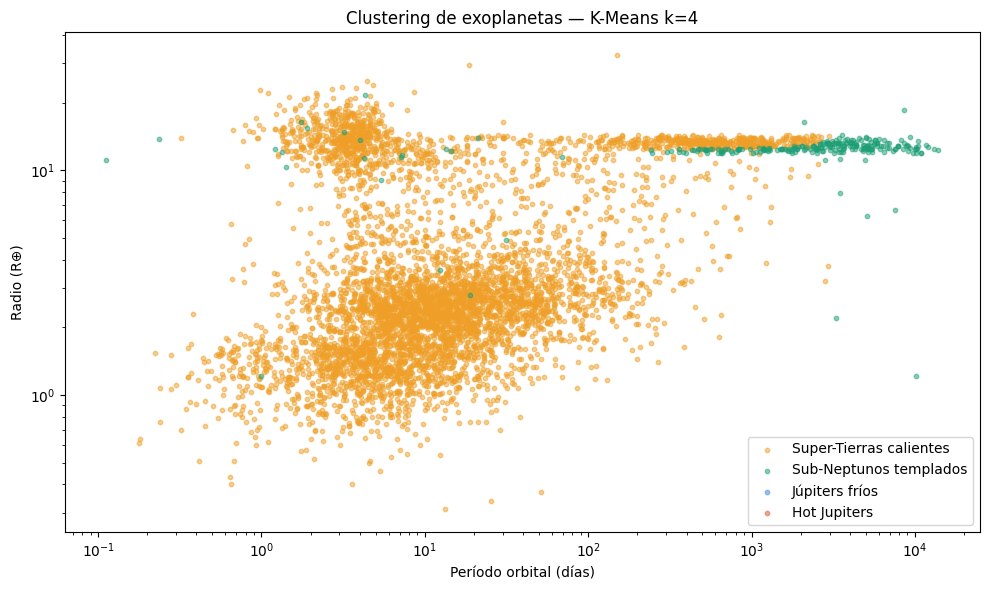

In [ ]:
colores = {
    0.0: '#EF9F27',
    1.0: '#1D9E75',
    2.0: '#378ADD',
    3.0: '#D85A30'
}

nombres = {
    0.0: 'Super-Tierras calientes',
    1.0: 'Sub-Neptunos templados',
    2.0: 'Júpiters fríos',
    3.0: 'Hot Jupiters'
}

fig, ax = plt.subplots(figsize=(10, 6))

for cluster in [0.0, 1.0, 2.0, 3.0]:
    sub = planetas[planetas['cluster_kmeans'] == cluster]
    ax.scatter(sub['pl_orbper'], sub['pl_rade'],
               c=colores[cluster], s=10, alpha=0.5,
               label=nombres[cluster])

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Período orbital (días)')
ax.set_ylabel('Radio (R⊕)')
ax.set_title('Clustering de exoplanetas — K-Means k=4')
ax.legend()
plt.tight_layout()
plt.show()

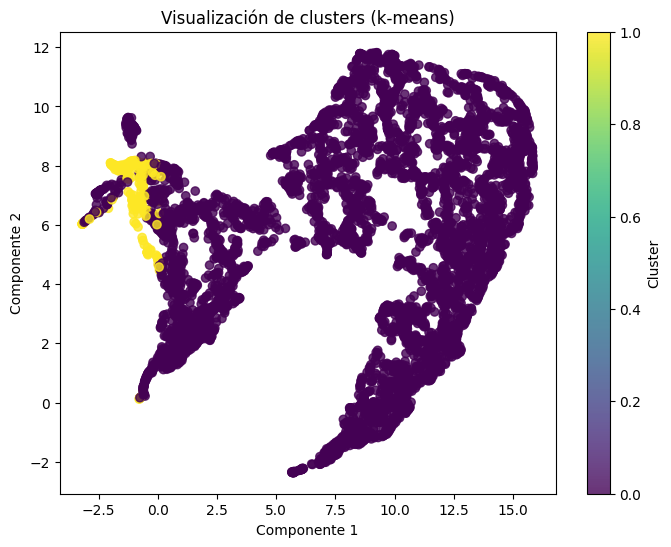

In [ ]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pos[:, 0], X_pos[:, 1], c=labels, cmap='viridis', alpha=0.8)
plt.colorbar(scatter, label='Cluster')
plt.title('Visualización de clusters (k-means)')
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.savefig("k-means.png")
plt.show()

In [ ]:
silhouette = silhouette_score(X_scaled, labels)
print(f"Silueta: {silhouette}")

calinski_harabasz = calinski_harabasz_score(X_scaled, labels)
print(f"Calinski-Harabasz: {calinski_harabasz}")

Counter(labels)

Silueta: 0.7032382728800174
Calinski-Harabasz: 1539.0055483919639


Counter({np.int32(1): 250, np.int32(0): 5578})

Para habitabilidad buscamos:
- Energía recibida (T_eq/insolación hay agua líquida)
- Tipo de planeta
- Masa (si puede tener atmósfera)
  Hay que calcular las masas que no tenemos. Podemos checar si los que no tiene masa, tienen semi eje mayor a. a3=R2M, donde R es periodo orbital (ver si lo tienen) y M es la masa. En caso de que sea posible calcularlo, lo hacemos. Si no, eliminamos los datos.
- Excentricidad orbital (estabilidad térmica)

## OPTICS

In [ ]:
for k in range(5, 12):
    clusterer = OPTICS(min_samples=k, xi=0.1)
    labels = clusterer.fit_predict(X_scaled)

    # Excluir puntos etiquetados como ruido (-1)
    mask = labels != -1
    if np.sum(mask) == 0:
        print(f"k={k} -> Solo ruido, no se puede calcular silhouette")
        continue

    labels_filtered = labels[mask]
    X_filtered = X_scaled[mask]

    # Número de clústeres reales (excluyendo -1)
    n_clusters = len(set(labels_filtered))
    if n_clusters < 2:
        print(f"k={k} -> Un solo clúster ({n_clusters}), silhouette no definida")
        continue

    silhouette = silhouette_score(X_scaled, labels)
    calinski_harabasz = calinski_harabasz_score(X_scaled, labels)
    print(f"k={k} -> Clústeres: \t{n_clusters},\tSilhouette:{silhouette:.3f}\tCHS: {calinski_harabasz:.3f}")

k=5 -> Clústeres: 	68,	Silhouette:-0.659	CHS: 4.162
k=6 -> Clústeres: 	34,	Silhouette:-0.634	CHS: 4.206
k=7 -> Clústeres: 	18,	Silhouette:-0.622	CHS: 8.134
k=8 -> Clústeres: 	10,	Silhouette:-0.537	CHS: 10.840
k=9 -> Clústeres: 	2,	Silhouette:-0.209	CHS: 7.216
k=10 -> Clústeres: 	2,	Silhouette:0.097	CHS: 17.739
k=11 -> Un solo clúster (1), silhouette no definida


In [ ]:
optics = OPTICS(min_samples=10, xi=0.1)
labels = optics.fit_predict(X_scaled)

# Número de clústeres detectados (sin ruido)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print(f"Clústeres: {n_clusters}, Ruido: {sum(labels==-1)}")
print(f"Silueta: {silhouette}")

Clústeres: 2, Ruido: 5791
Silueta: 0.0965400425973796


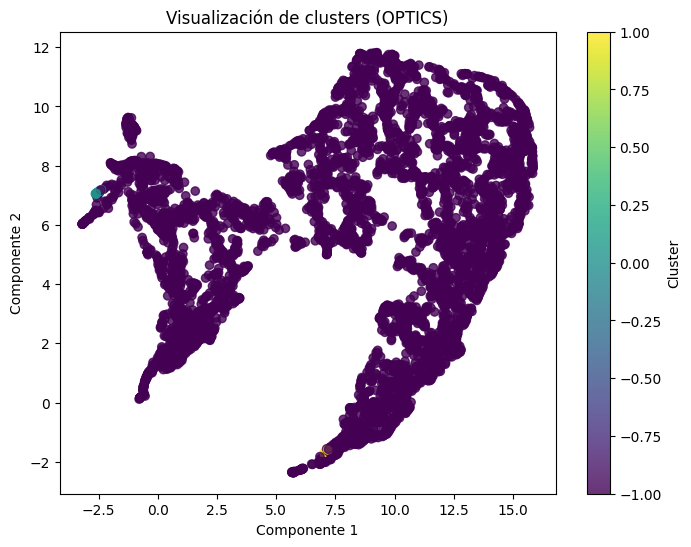

In [ ]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pos[:, 0], X_pos[:, 1], c=labels, cmap='viridis', alpha=0.8)
plt.colorbar(scatter, label='Cluster')
plt.title('Visualización de clusters (OPTICS)')
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.savefig("optics.png")
plt.show()

In [ ]:
silhouette = silhouette_score(X_scaled, labels)
print(f"Silueta: {silhouette}")

calinski_harabasz = calinski_harabasz_score(X_scaled, labels)
print(f"Calinski-Harabasz: {calinski_harabasz}")

Counter(labels)

Silueta: 0.0965400425973796
Calinski-Harabasz: 17.738692970697496


Counter({np.int64(-1): 5791, np.int64(0): 24, np.int64(1): 13})

## HDBSCAN

In [ ]:
for k in range(2, 100, 2):
    clusterer = hdbscan.HDBSCAN(min_cluster_size=k)
    labels = clusterer.fit_predict(X_scaled)

    # Excluir puntos etiquetados como ruido (-1)
    mask = labels != -1
    if np.sum(mask) == 0:
        print(f"k={k} -> Solo ruido, no se puede calcular silhouette")
        continue

    labels_filtered = labels[mask]
    X_filtered = X_scaled[mask]

    # Número de clústeres reales (excluyendo -1)
    n_clusters = len(set(labels_filtered))
    if n_clusters < 2:
        print(f"k={k} -> Un solo clúster ({n_clusters}), silhouette no definida")
        continue

    silhouette = silhouette_score(X_scaled, labels)
    calinski_harabasz = calinski_harabasz_score(X_scaled, labels)
    print(f"k={k} -> Clústeres: \t{n_clusters},\tSilhouette:{silhouette:.3f}\tCHS: {calinski_harabasz:.3f}")

k=2 -> Clústeres: 	616,	Silhouette:-0.306	CHS: 5.747
k=4 -> Clústeres: 	2,	Silhouette:0.823	CHS: 350.819
k=6 -> Clústeres: 	26,	Silhouette:-0.368	CHS: 30.959
k=8 -> Clústeres: 	15,	Silhouette:-0.321	CHS: 50.705
k=10 -> Clústeres: 	6,	Silhouette:0.151	CHS: 202.932
k=12 -> Clústeres: 	5,	Silhouette:0.170	CHS: 253.644
k=14 -> Clústeres: 	4,	Silhouette:0.241	CHS: 313.875
k=16 -> Clústeres: 	3,	Silhouette:0.252	CHS: 432.073
k=18 -> Clústeres: 	3,	Silhouette:0.221	CHS: 384.152
k=20 -> Clústeres: 	3,	Silhouette:0.222	CHS: 380.174
k=22 -> Clústeres: 	3,	Silhouette:0.228	CHS: 388.804
k=24 -> Clústeres: 	3,	Silhouette:0.226	CHS: 384.156
k=26 -> Clústeres: 	3,	Silhouette:0.221	CHS: 379.231
k=28 -> Clústeres: 	3,	Silhouette:0.217	CHS: 373.756
k=30 -> Clústeres: 	2,	Silhouette:0.252	CHS: 549.688
k=32 -> Clústeres: 	2,	Silhouette:0.255	CHS: 552.146
k=34 -> Clústeres: 	2,	Silhouette:0.256	CHS: 555.470
k=36 -> Clústeres: 	2,	Silhouette:0.256	CHS: 554.961
k=38 -> Clústeres: 	2,	Silhouette:0.257	CHS: 55

In [ ]:
clusterer = hdbscan.HDBSCAN(min_cluster_size=68)
labels = clusterer.fit_predict(X_scaled)

# Resultados
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = np.sum(labels == -1)
print(f"Clústeres encontrados: {n_clusters}")
print(f"Puntos ruido: {n_noise}")


Clústeres encontrados: 2
Puntos ruido: 2056


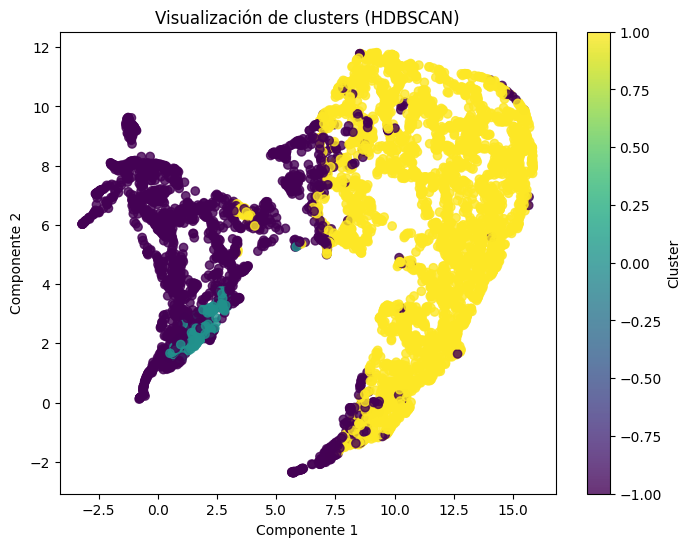

In [ ]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pos[:, 0], X_pos[:, 1], c=labels, cmap='viridis', alpha=0.8)
plt.colorbar(scatter, label='Cluster')
plt.title('Visualización de clusters (HDBSCAN)')
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.savefig("hdbscan.png")
plt.show()

In [ ]:
silhouette = silhouette_score(X_scaled, labels)
print(f"Silueta: {silhouette}")

calinski_harabasz = calinski_harabasz_score(X_scaled, labels)
print(f"Calinski-Harabasz: {calinski_harabasz}")

Counter(labels)

Silueta: 0.26382832474503365
Calinski-Harabasz: 563.5264253627088


Counter({np.int64(-1): 2056, np.int64(0): 197, np.int64(1): 3575})

## Clustering Aglomerativo

### Single

In [ ]:
for k in range(2, 10):
    clusterer = AgglomerativeClustering(n_clusters=k, linkage="single")
    labels = clusterer.fit_predict(X_scaled)

    silhouette = silhouette_score(X_scaled, labels)
    calinski_harabasz = calinski_harabasz_score(X_scaled, labels)
    print(f"k={k} -> Clústeres: \t{k},\tSilhouette:{silhouette:.3f}\tCHS: {calinski_harabasz:.3f}")

k=2 -> Clústeres: 	2,	Silhouette:0.910	CHS: 257.312
k=3 -> Clústeres: 	3,	Silhouette:0.910	CHS: 278.201
k=4 -> Clústeres: 	4,	Silhouette:0.865	CHS: 228.298
k=5 -> Clústeres: 	5,	Silhouette:0.838	CHS: 246.493
k=6 -> Clústeres: 	6,	Silhouette:0.838	CHS: 210.753
k=7 -> Clústeres: 	7,	Silhouette:0.833	CHS: 177.541
k=8 -> Clústeres: 	8,	Silhouette:0.831	CHS: 154.031
k=9 -> Clústeres: 	9,	Silhouette:0.817	CHS: 135.568


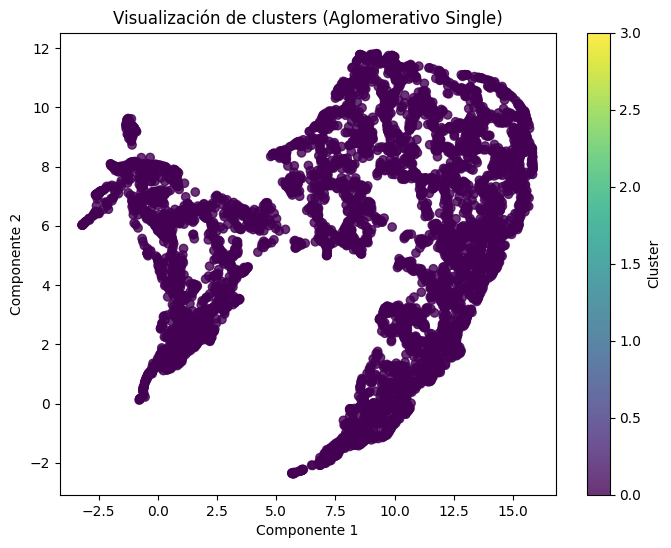

Silueta: 0.8647561708720953
Calinski-Harabasz: 228.2984584813005


Counter({np.int64(0): 5822, np.int64(2): 2, np.int64(3): 2, np.int64(1): 2})

In [ ]:
clusterer = AgglomerativeClustering(n_clusters=4, linkage="single")
labels = clusterer.fit_predict(X_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pos[:, 0], X_pos[:, 1], c=labels, cmap='viridis', alpha=0.8)
plt.colorbar(scatter, label='Cluster')
plt.title('Visualización de clusters (Aglomerativo Single)')
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.savefig("Agglomerative single.png")
plt.show()

silhouette = silhouette_score(X_scaled, labels)
print(f"Silueta: {silhouette}")

calinski_harabasz = calinski_harabasz_score(X_scaled, labels)
print(f"Calinski-Harabasz: {calinski_harabasz}")

Counter(labels)

### Average

In [ ]:
for k in range(2, 10):
    clusterer = AgglomerativeClustering(n_clusters=k, linkage="average")
    labels = clusterer.fit_predict(X_scaled)

    silhouette = silhouette_score(X_scaled, labels)
    calinski_harabasz = calinski_harabasz_score(X_scaled, labels)
    print(f"k={k} -> Clústeres: \t{k},\tSilhouette:{silhouette:.3f}\tCHS: {calinski_harabasz:.3f}")

k=2 -> Clústeres: 	2,	Silhouette:0.900	CHS: 312.707
k=3 -> Clústeres: 	3,	Silhouette:0.864	CHS: 454.524
k=4 -> Clústeres: 	4,	Silhouette:0.860	CHS: 444.698
k=5 -> Clústeres: 	5,	Silhouette:0.845	CHS: 353.447
k=6 -> Clústeres: 	6,	Silhouette:0.838	CHS: 295.217
k=7 -> Clústeres: 	7,	Silhouette:0.791	CHS: 431.417
k=8 -> Clústeres: 	8,	Silhouette:0.791	CHS: 373.874
k=9 -> Clústeres: 	9,	Silhouette:0.790	CHS: 329.279


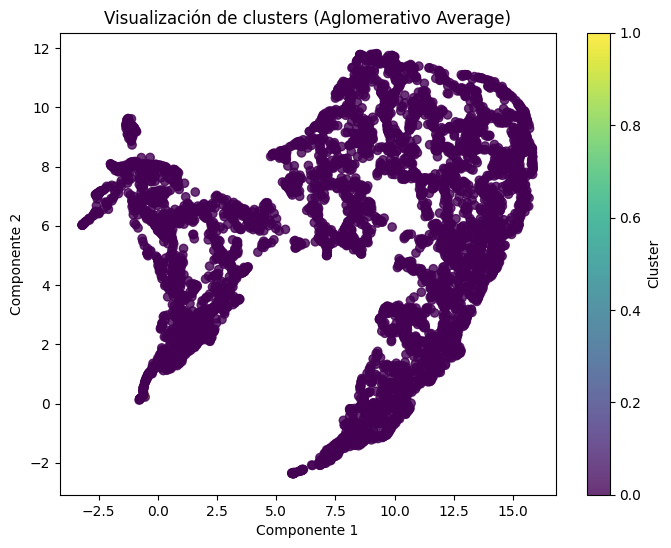

Silueta: 0.9000743497692946
Calinski-Harabasz: 312.7074574175947


Counter({np.int64(0): 5825, np.int64(1): 3})

In [ ]:
clusterer = AgglomerativeClustering(n_clusters=2, linkage="average")
labels = clusterer.fit_predict(X_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pos[:, 0], X_pos[:, 1], c=labels, cmap='viridis', alpha=0.8)
plt.colorbar(scatter, label='Cluster')
plt.title('Visualización de clusters (Aglomerativo Average)')
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.savefig("Agglomerative average.png")
plt.show()

silhouette = silhouette_score(X_scaled, labels)
print(f"Silueta: {silhouette}")

calinski_harabasz = calinski_harabasz_score(X_scaled, labels)
print(f"Calinski-Harabasz: {calinski_harabasz}")

Counter(labels)

### Ward

In [ ]:
for k in range(2, 10):
    clusterer = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = clusterer.fit_predict(X_scaled)

    silhouette = silhouette_score(X_scaled, labels)
    calinski_harabasz = calinski_harabasz_score(X_scaled, labels)
    print(f"k={k} -> Clústeres: \t{k},\tSilhouette:{silhouette:.3f}\tCHS: {calinski_harabasz:.3f}")

k=2 -> Clústeres: 	2,	Silhouette:0.561	CHS: 1628.540
k=3 -> Clústeres: 	3,	Silhouette:0.477	CHS: 1371.745
k=4 -> Clústeres: 	4,	Silhouette:0.447	CHS: 1305.423
k=5 -> Clústeres: 	5,	Silhouette:0.457	CHS: 1359.434
k=6 -> Clústeres: 	6,	Silhouette:0.465	CHS: 1473.289
k=7 -> Clústeres: 	7,	Silhouette:0.466	CHS: 1424.696
k=8 -> Clústeres: 	8,	Silhouette:0.467	CHS: 1374.457
k=9 -> Clústeres: 	9,	Silhouette:0.469	CHS: 1350.156


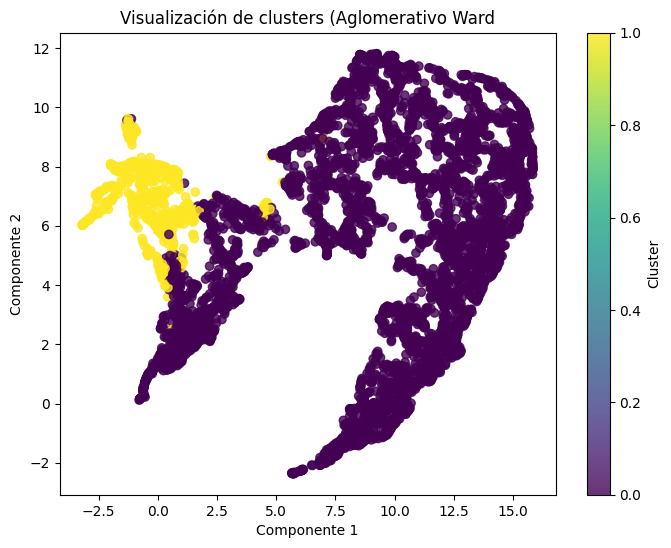

Silueta: 0.5606747116421444
Calinski-Harabasz: 1628.5401113813189


Counter({np.int64(1): 740, np.int64(0): 5088})

In [ ]:
clusterer = AgglomerativeClustering(n_clusters=2, linkage="ward")
labels = clusterer.fit_predict(X_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pos[:, 0], X_pos[:, 1], c=labels, cmap='viridis', alpha=0.8)
plt.colorbar(scatter, label='Cluster')
plt.title('Visualización de clusters (Aglomerativo Ward')
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.savefig("Agglomerative ward.png")
plt.show()

silhouette = silhouette_score(X_scaled, labels)
print(f"Silueta: {silhouette}")

calinski_harabasz = calinski_harabasz_score(X_scaled, labels)
print(f"Calinski-Harabasz: {calinski_harabasz}")

Counter(labels)

In [ ]:
planetas['densidad_gcm3'] = 5.51 * (planetas['pl_bmasse'] / (planetas['pl_rade'] ** 3))


# Criterio de habitabilidad

**Criterio de habitabilidad **
Radio 0.5 R_T - 2 R_T
Masa 0.1 M_T - 10 M_T
Densidad 3-7 g/cm3
Temperatura de equilibrio  275 K < Teq< 315 K
Excentricidad <0.3
 era este ?

In [ ]:
def es_habitable(row):
    if not (0.5 <= row['pl_rade'] <= 2):
        return False

    if not (0.1 <= row['pl_bmasse'] <= 10):
        return False

    if pd.isna(row['pl_orbeccen']) or row['pl_orbeccen'] > 0.3:
        return False

    if pd.isna(row['densidad_gcm3']) or not (3 <= row['densidad_gcm3'] <= 7):
        return False

    if pd.notna(row['pl_insol']):
        if not (0.75 <= row['pl_insol'] <= 1.5):
            return False
    elif pd.notna(row['pl_eqt']):
        if not (275 <= row['pl_eqt'] <= 315):
            return False
    else:
        return False

    return True

planetas['habitable'] = planetas.apply(es_habitable, axis=1)
print(f"Planetas potencialmente habitables: {planetas['habitable'].sum()}")




Planetas potencialmente habitables: 21


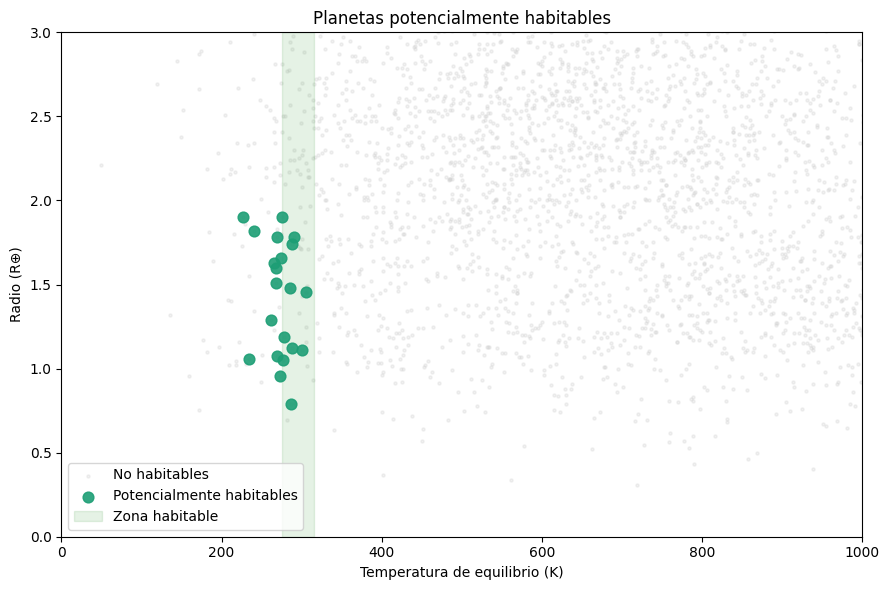

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))

# Todos los planetas
ax.scatter(planetas['pl_eqt'], planetas['pl_rade'],
           c='lightgray', s=5, alpha=0.3, label='No habitables')

# Habitables
hab = planetas[planetas['habitable'] == True]
ax.scatter(hab['pl_eqt'], hab['pl_rade'],
           c='#1D9E75', s=60, alpha=0.9, label='Potencialmente habitables', zorder=5)

# Zona habitable
ax.axvspan(275, 315, alpha=0.1, color='green', label='Zona habitable')

ax.set_xlabel('Temperatura de equilibrio (K)')
ax.set_ylabel('Radio (R⊕)')
ax.set_title('Planetas potencialmente habitables')
ax.set_xlim(0, 1000)
ax.set_ylim(0, 3)
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
habitables = planetas[planetas['habitable'] == True][['pl_name', 'pl_rade', 'pl_bmasse', 'pl_eqt', 'pl_orbeccen', 'pl_orbper', 'tipo_planeta']].sort_values('pl_eqt')

print(habitables.to_string(index=False))

           pl_name  pl_rade  pl_bmasse     pl_eqt  pl_orbeccen  pl_orbper tipo_planeta
        K2-288 B b    1.900      4.270 226.360000      0.11900  31.393463 Super-Tierra
     Kepler-1649 c    1.060      1.200 234.000000      0.00000  19.535270    Terrestre
      Kepler-283 c    1.820      3.970 240.000000      0.00000  92.743711 Super-Tierra
           K2-72 e    1.290      2.210 261.913924      0.11000  24.158868 Super-Tierra
      Kepler-452 b    1.630      3.290 265.000000      0.00000 384.843000 Super-Tierra
          GJ 273 b    1.510      2.890 267.516491      0.10000  18.649800 Super-Tierra
     Kepler-1652 b    1.600      3.190 268.000000      0.00000  38.097220 Super-Tierra
         TOI-700 d    1.073      1.250 268.800000      0.04200  37.423960    Terrestre
     Kepler-1544 b    1.780      3.820 269.000000      0.00000 168.811174 Super-Tierra
         TOI-700 e    0.953      0.818 272.900000      0.05900  27.809780    Terrestre
       Wolf 1061 c    1.660      3.410 273.

'Tierra radio : 1.0 masa: 1.0, temperatura de equilibrio 288. exentricidad: 0.017, 'perido de orbitaje ': 365.25, tipo_planeta: 'Terrestre'

Como se detectan
Detection Method:
Transit

If a planet passes directly between a star and an observer's line of sight, it blocks out a tiny portion of the star's light, thus reducing its apparent brightness.

 Sensitive instruments can detect this periodic dip in brightness. From the period and depth of the transits, the orbit and size of the planetary companions can be calculated. Smaller planets will produce a smaller effect, and vice-versa. A terrestrial planet in an Earth-like orbit, for example, would produce a minute dip in stellar brightness that would last just a few hours.

# Clasificación de planetas

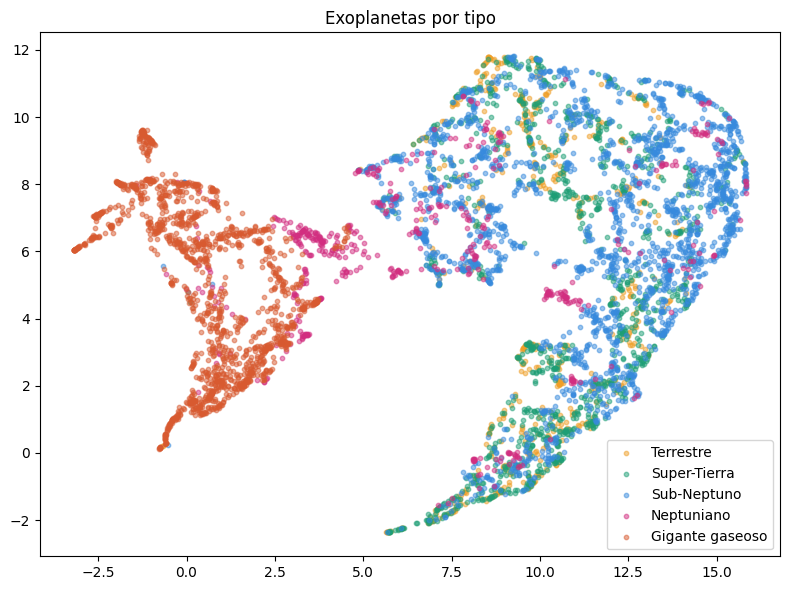

In [ ]:
colores = ['#EF9F27', '#1D9E75', '#378ADD', '#D22E80', '#D85A30', '#888780']
nombres = ['Terrestre', 'Super-Tierra', 'Sub-Neptuno', 'Neptuniano', 'Gigante gaseoso']

fig, ax = plt.subplots(figsize=(8, 6))

for i in range(5):
    sub = planetas[planetas["tipo_planeta"] == nombres[i]]
    ax.scatter(sub['x'], sub['y'],
               c=colores[i], s=10, alpha=0.5,
               label=nombres[i])

ax.set_title('Exoplanetas por tipo')
ax.legend()
plt.tight_layout()
plt.savefig("Exoplanetas Tipo.png")
plt.show()

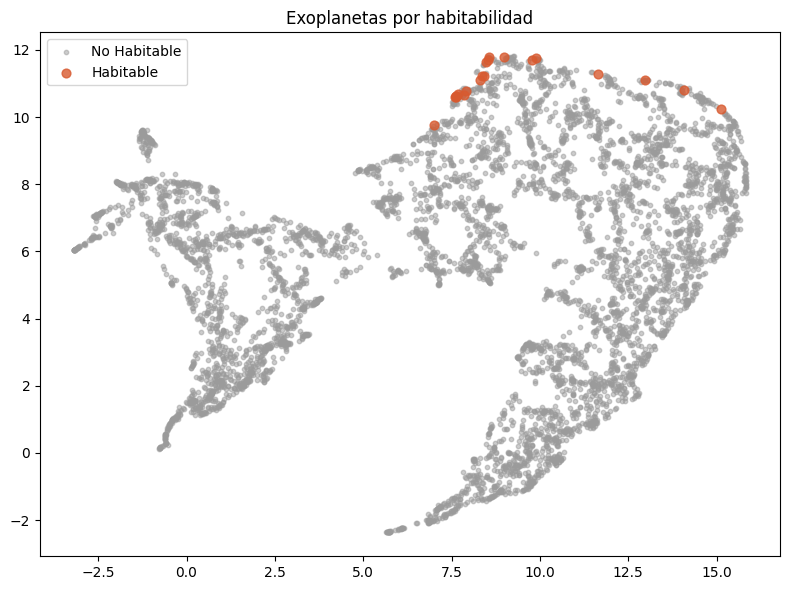

In [ ]:
colores = ['#9B9B9B', '#D85A30']
etiquetas = [False, True]
nombres = ["No Habitable", "Habitable"]

fig, ax = plt.subplots(figsize=(8, 6))

for i in range(2):
    sub = planetas[planetas["habitable"] == etiquetas[i]]
    ax.scatter(sub['x'], sub['y'],
               c=colores[i], s=40 if i == 1 else 10, alpha=0.8 if i == 1 else 0.5,
               label=nombres[i])

ax.set_title('Exoplanetas por habitabilidad')
ax.legend()
plt.tight_layout()
plt.savefig("Exoplanetas Habitabilidad.png")
plt.show()